In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
ticker = "^GSPC"
data = yf.download(ticker, start="2023-01-01", end="2026-09-01",auto_adjust=True, progress=False
                  ).droplevel(['Ticker'], axis=1).reset_index(drop=False).rename_axis(i)

In [18]:
data['Return'] = data.Close.pct_change()
data['Direction'] = (data['Return'] > 0).astype(int)
data["MA5"] = data["Close"].rolling(5).mean() / data["Close"]
data["MA20"] = data["Close"].rolling(20).mean() / data["Close"]
data["Volatility_5"] = data["Return"].rolling(5).std()
data = data.dropna(axis=0)
data.head()

Price,Date,Close,High,Low,Open,Volume,Return,Direction,MA5,MA20,Volatility_5
^GSPC,,,,,,,,,,,
19,2023-01-31,4076.600098,4077.159912,4020.439941,4020.850098,4679320000,0.014642,1,0.993062,0.971559,0.010783
20,2023-02-01,4119.209961,4148.950195,4037.199951,4070.070068,4856930000,0.010452,1,0.987790,0.965090,0.011044
21,2023-02-02,4179.759766,4195.439941,4141.879883,4158.680176,5624360000,0.014699,1,0.979190,0.955019,0.011643
22,2023-02-03,4136.479980,4182.359863,4123.359863,4136.689941,4694510000,-0.010355,0,0.992623,0.968981,0.013792
23,2023-02-06,4111.080078,4124.629883,4093.379883,4119.569824,4114240000,-0.006140,0,1.003295,0.977594,0.012001


## Regression

In [20]:
y_reg = data["Return"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

reg_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
print(f"RMSE    : {root_mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"MAE     : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")

RMSE    : 0.0057
MAE     : 0.0045
R2 Score: 0.5280


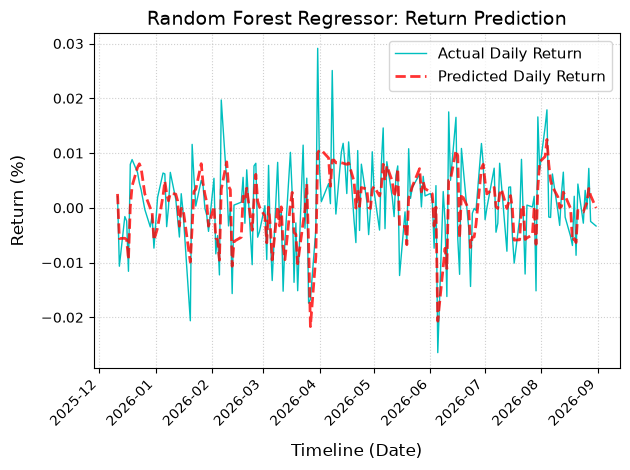

In [21]:
plt.plot(data['Date'][split_idx:], data['Return'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
plt.plot(data['Date'][split_idx:], y_pred_r, 'r--', label="Predicted Daily Return", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Return Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Return (%)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Classification

In [22]:
y_cl = data["Direction"]
X_cl = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data) * 0.8)
X_train_c, X_test_c = X_cl.iloc[:split_idx], X_cl.iloc[split_idx:]
y_train_c, y_test_c = y_cl.iloc[:split_idx], y_cl.iloc[split_idx:]

reg_model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1)
reg_model.fit(X_train_c, y_train_c)
y_pred_c = reg_model.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74        85
           1       0.77      0.77      0.77        95

    accuracy                           0.76       180
   macro avg       0.75      0.75      0.75       180
weighted avg       0.76      0.76      0.76       180



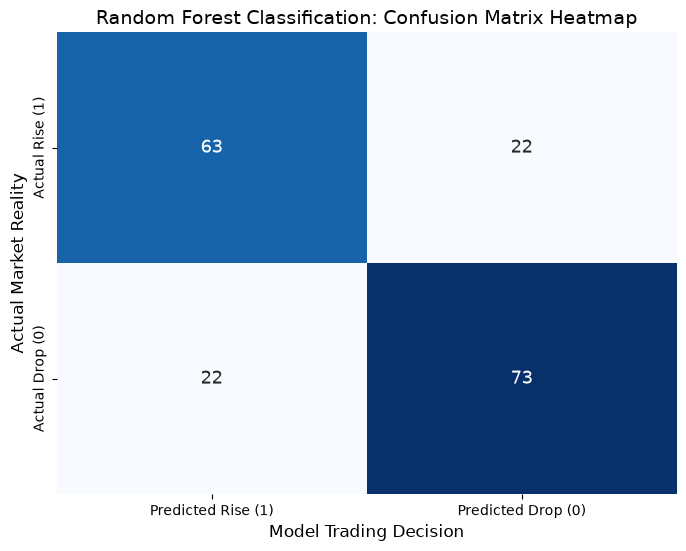

In [24]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(8, 6), dpi=100)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Rise (1)", "Predicted Drop (0)"],
    yticklabels=["Actual Rise (1)", "Actual Drop (0)"],
    annot_kws={"size": 13},
    cbar=False
)

plt.title("Random Forest Classification: Confusion Matrix Heatmap", fontsize=14)
plt.ylabel("Actual Market Reality", fontsize=12)
plt.xlabel("Model Trading Decision", fontsize=12)
plt.show()